In [36]:
import pandas as pd
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import glob

# Directory path where the cases are stored
base_dir = '/workspaces/CUBES/exp/jack/paper/thermostat_experiment/SI/latest_run'

def load_json_file(file_type, case_number, zone_number):
    # Use glob to find the correct file path dynamically
    json_file_pattern = f'{base_dir}/case_{case_number}_year_2023_rep_H28_zone_{zone_number}_*/{file_type}.json'

    # Get the list of files that match the pattern
    matching_files = glob.glob(json_file_pattern)

    # Load and return the JSON data from the matched file
    with open(matching_files[0], 'r') as file:
        return json.load(file)




In [37]:
data_case_0 = load_json_file("hourly_metrics", 0, zone_number=0)

In [40]:
df_case_0 = pd.DataFrame(data_case_0['hourly_data']) * 60

In [41]:
df_case_0

,hour,emissions,cost,gas_cost,electricity_cost,electricity_surplus,gas_energy,electricity_energy,net_electricity_energy
0,60,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0
1,120,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0
2,180,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0
3,240,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0
4,300,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...
8756,525420,1.092161,25.087036,25.087036,0.0,0.0,5.834194,0.0,0.0
8757,525480,1.049304,24.102600,24.102600,0.0,0.0,5.605256,0.0,0.0
8758,525540,1.023475,23.509311,23.509311,0.0,0.0,5.467282,0.0,0.0
8759,525600,0.014247,0.327266,0.327266,0.0,0.0,0.076108,0.0,0.0


In [58]:
import pandas as pd
import matplotlib.dates as mdates

def plot_metric_figure(metric):

    # Set normalisation factor based on the metric type
    if "cost" in metric:
        normalise = 100  # Convert pence to pounds
    elif "emission" in metric:
        normalise = 1000  # Convert grams to kilograms
    else:
        normalise = 1  # No normalisation needed

    # Create the 5x3 plot grid
    fig, axes = plt.subplots(3, 5, figsize=(20, 12))
    axes = axes.flatten()

    # Define the order of cases for the rows
    case_order = [10, 11, 12, 13, 14, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4]

    # Create a DateTime index starting from Jan 1 of the year for 8760 hours (non-leap year)
    time_index = pd.date_range(start="2023-01-01", periods=8760, freq="H")

    # Load the JSON data for case 0, zone 0 (to plot on all subplots)
    data_case_0 = load_json_file("hourly_metrics", 0, zone_number=0)
    df_case_0 = pd.DataFrame(data_case_0['hourly_data']) * 60

    # Truncate the DataFrame to match 8760 rows
    df_case_0 = df_case_0.iloc[:8760]
    df_case_0.index = time_index  # Assign the DateTime index
    df_case_0[f'cumulative_{metric}'] = df_case_0[f'{metric}'].cumsum() / normalise

    # Variables to track the global minimum and maximum y values
    global_max_y = float('-inf')
    global_min_y = float('inf')

    # Loop over the cases from 0 to 14, but use case_order to assign them to subplots
    for i, case_number in enumerate(case_order):
        # Load the JSON data for the current case, zone 0 and zone 9
        data_zone_0 = load_json_file("hourly_metrics", case_number, zone_number=0)
        data_zone_9 = load_json_file("hourly_metrics", case_number, zone_number=9)

        df_zone_0 = pd.DataFrame(data_zone_0['hourly_data']) * 60
        df_zone_9 = pd.DataFrame(data_zone_9['hourly_data']) * 60

        # Truncate the DataFrames to match 8760 rows
        df_zone_0 = df_zone_0.iloc[:8760]
        df_zone_9 = df_zone_9.iloc[:8760]

        df_zone_0.index = time_index  # Assign the DateTime index
        df_zone_9.index = time_index  # Assign the DateTime index

        # Calculate the cumulative sum of the specified metric for both zones
        df_zone_0[f'cumulative_{metric}'] = df_zone_0[f'{metric}'].cumsum() / normalise
        df_zone_9[f'cumulative_{metric}'] = df_zone_9[f'{metric}'].cumsum() / normalise

        # Update global_max_y and global_min_y with the current maximum and minimum y values
        global_max_y = max(global_max_y, df_zone_0[f'cumulative_{metric}'].max(), df_zone_9[f'cumulative_{metric}'].max())
        global_min_y = min(global_min_y, df_zone_0[f'cumulative_{metric}'].min(), df_zone_9[f'cumulative_{metric}'].min())

        # Plot the cumulative metric on the subplot for this case
        ax = axes[i]

        # Plot case 0 metric (zone 0) as a light grey dashed line in all subplots
        ax.plot(df_case_0.index, df_case_0[f'cumulative_{metric}'], color='lightgray', linestyle='--', label=f'Case 0, Zone 0')

        # Plot current case metric for zone 0 as a solid black line
        ax.plot(df_zone_0.index, df_zone_0[f'cumulative_{metric}'], color='black', label=f'Case {case_number}, Zone 0')

        # Plot current case metric for zone 9 as a solid blue line
        ax.plot(df_zone_9.index, df_zone_9[f'cumulative_{metric}'], color='blue', linestyle='--', label=f'Case {case_number}, Zone 9')

        # Set the x-axis to show every 3 months
        ax.xaxis.set_major_locator(mdates.MonthLocator([1, 3, 5, 7, 9, 11]))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

        #ax.set_xlim([pd.Timestamp('2023-01-01'), pd.Timestamp('2023-12-31')])

        ax.set_title(f'Case {case_number}')
        ax.set_xlabel('Month')
        ax.set_ylabel(f'Cumulative {metric.capitalize()}')
        ax.grid(True)

    # Apply the global max and min y limits to all subplots
    for ax in axes:
        ax.set_ylim(global_min_y, global_max_y)

    # Adjust the layout and display the plot
    plt.tight_layout()
    plt.show()


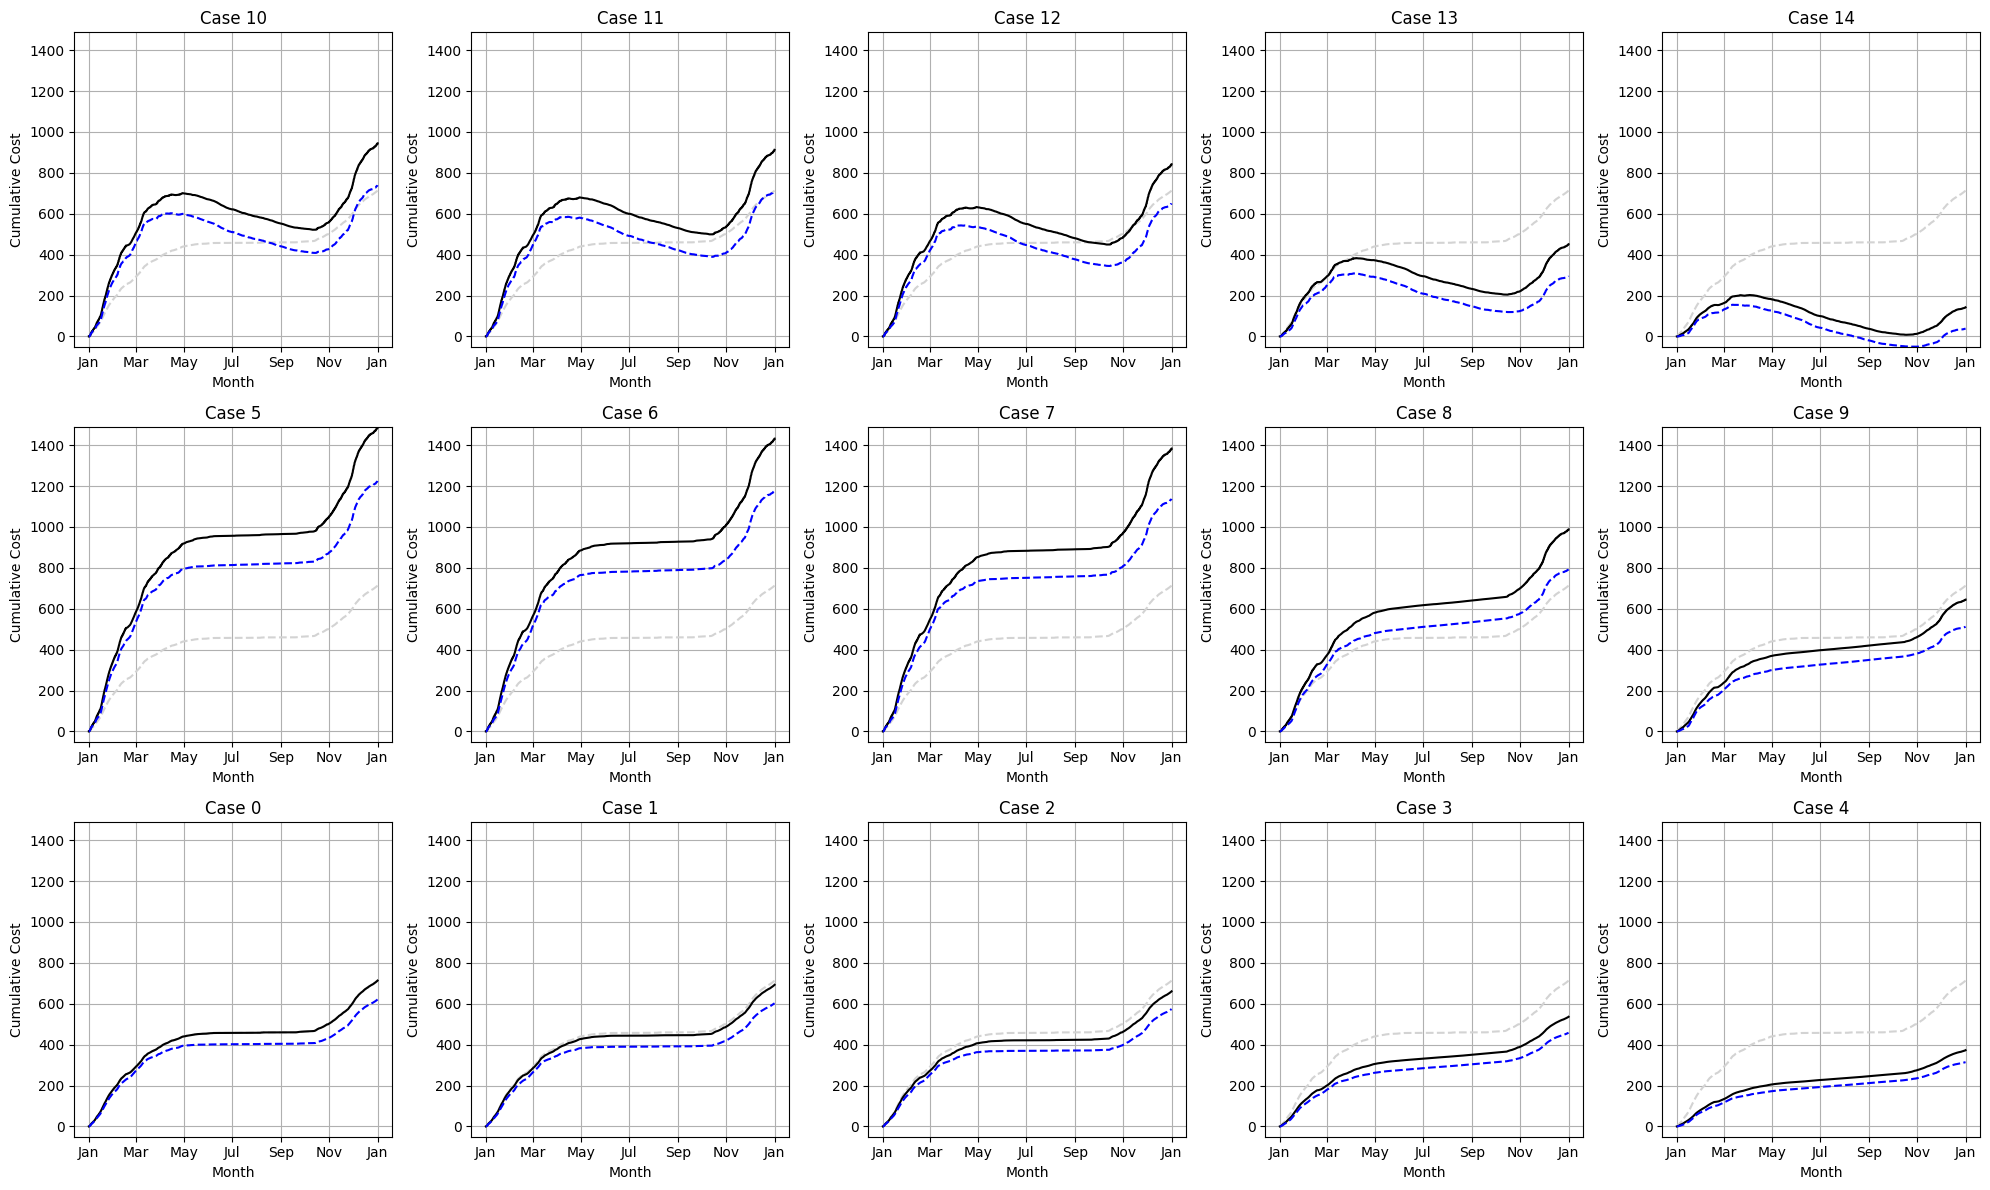

In [62]:
plot_metric_figure('cost')

In [ ]:
import pandas as pd
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import glob

# Directory path where the cases are stored
base_dir = '/workspaces/CUBES/exp/jack/paper/thermostat_experiment/SI/latest_run'

def load_json_file(case_number, zone_number):
    # Use glob to find the correct file path dynamically
    json_file_pattern = f'{base_dir}/case_{case_number}_year_2023_rep_H28_zone_{zone_number}_*/temp.json'

    # Get the list of files that match the pattern
    matching_files = glob.glob(json_file_pattern)

    # Load and return the JSON data from the matched file
    with open(matching_files[0], 'r') as file:
        return json.load(file)


# Function to normalise JSON data
def json_normalise_temperature(df):
    df[['Temperature', 'Percentage_Time']] = pd.json_normalize(df['percentage_time'])
    df = df.drop(columns=['percentage_time'])
    return df

# Function to calculate the combined counts and percentages
def calculate_combined_percentage(in_df, out_df, count_df_in, count_df_out):
    combined_data = []
    for zone in in_df['zone']:
        in_percentage = in_df.loc[in_df['zone'] == zone, 'Percentage_Time'].values[0]
        out_percentage = out_df.loc[out_df['zone'] == zone, 'Percentage_Time'].values[0]
        in_count = count_df_in.loc[count_df_in['zone'] == zone, 'total_count'].values[0]
        out_count = count_df_out.loc[count_df_out['zone'] == zone, 'total_count'].values[0]
        actual_in_time = np.array(in_percentage) * in_count
        actual_out_time = np.array(out_percentage) * out_count
        total_time_at_temp = actual_in_time + actual_out_time
        percentage_time = (total_time_at_temp / minutes_in_year) * 100
        combined_data.append({
            'zone': zone,
            'Temperature': in_df.loc[in_df['zone'] == zone, 'Temperature'].values[0],
            'Percentage_Time': percentage_time.tolist(),
            'total_count': in_count + out_count
        })
    return pd.DataFrame(combined_data)

# Function to calculate the weighted average percentage time across rooms
def calculate_weighted_percentage(df, zone_to_area, total_floor_area,):
    total_weighted_time = np.zeros(len(df['Temperature'].iloc[0]))
    for _, row in df.iterrows():
        zone = row['zone']
        area = zone_to_area.get(zone, 0)
        total_count = row['total_count']
        weighted_time = (np.array(row['Percentage_Time']) * total_count) * (area / total_floor_area)
        total_weighted_time += weighted_time
    weighted_percentage = total_weighted_time / minutes_in_year
    return weighted_percentage

# Number of minutes in a year (non-leap year)
minutes_in_year = 525600

# Room areas
room_areas = {
    'front_room': 14.04,
    'kitchen': 11.34,
    'backroom': 11.34,
    'hall_downstairs': 7.02,
    'bedroom_1': 11.51,
    'bedroom_2': 12.39,
    'bedroom_3': 6.86,
    'bathroom': 7.105,
    'hall_upstairs': 5.88
}
total_floor_area = sum(room_areas.values())

# Map zones to room areas
zone_to_area = {
    'front_room': room_areas['front_room'],
    'kitchen': room_areas['kitchen'],
    'backroom': room_areas['backroom'],
    'hall_downstairs': room_areas['hall_downstairs'],
    'bedroom_1': room_areas['bedroom_1'],
    'bedroom_2': room_areas['bedroom_2'],
    'bedroom_3': room_areas['bedroom_3'],
    'bathroom': room_areas['bathroom'],
    'hall_upstairs': room_areas['hall_upstairs'],
}


def plot_figure(temp_type):
    if temp_type == "air":
        temp_type = f"{temp_type}_temp"
    else:
        temp_type = "operative_temp"

    # Create the 5x3 plot grid
    fig, axes = plt.subplots(3, 5, figsize=(20, 12))
    axes = axes.flatten()

    # Define the order of cases for the rows
    case_order = [10, 11, 12, 13, 14, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4]

    # Load the data for case 0, zone 0 and calculate its weighted percentage time
    data_case_0_zone_0 = load_json_file(0, zone_number=0)

    df_in_hours_air_temp_percentage_0 = json_normalise_temperature(pd.DataFrame(data_case_0_zone_0['in_hours'][f'{temp_type}']['percentage_time'].items(), columns=['zone', 'percentage_time']))
    df_out_of_hours_air_temp_percentage_0 = json_normalise_temperature(pd.DataFrame(data_case_0_zone_0['out_of_hours'][f'{temp_type}']['percentage_time'].items(), columns=['zone', 'percentage_time']))
    df_in_hours_air_temp_count_0 = pd.DataFrame(data_case_0_zone_0['in_hours'][f'{temp_type}']['total_count'].items(), columns=['zone', 'total_count'])
    df_out_of_hours_air_temp_count_0 = pd.DataFrame(data_case_0_zone_0['out_of_hours'][f'{temp_type}']['total_count'].items(), columns=['zone', 'total_count'])

    # Calculate the combined percentage time for case 0, zone 0
    df_combined_air_temp_percentage_0 = calculate_combined_percentage(
        df_in_hours_air_temp_percentage_0,
        df_out_of_hours_air_temp_percentage_0,
        df_in_hours_air_temp_count_0,
        df_out_of_hours_air_temp_count_0
    )

    # Calculate the weighted percentage time for case 0, zone 0 air temperature
    weighted_percentage_air_temp_0 = calculate_weighted_percentage(df_combined_air_temp_percentage_0, zone_to_area, total_floor_area)

    # Get the temperature range for case 0, zone 0
    temperature_range_0 = df_combined_air_temp_percentage_0['Temperature'].iloc[0]

    # Loop over the cases from 0 to 14, but use case_order to assign them to subplots
    for i, case_number in enumerate(case_order):
        # Load the JSON data for the current case, zone 0 and zone 9
        data_zone_0 = load_json_file(case_number, zone_number=0)  # For zone 0
        data_zone_9 = load_json_file(case_number, zone_number=9)  # For zone 9

        # Normalise the temperature data for zone 0
        df_in_hours_air_temp_percentage_0_case = json_normalise_temperature(pd.DataFrame(data_zone_0['in_hours'][f'{temp_type}']['percentage_time'].items(), columns=['zone', 'percentage_time']))
        df_out_of_hours_air_temp_percentage_0_case = json_normalise_temperature(pd.DataFrame(data_zone_0['out_of_hours'][f'{temp_type}']['percentage_time'].items(), columns=['zone', 'percentage_time']))
        df_in_hours_air_temp_count_0_case = pd.DataFrame(data_zone_0['in_hours'][f'{temp_type}']['total_count'].items(), columns=['zone', 'total_count'])
        df_out_of_hours_air_temp_count_0_case = pd.DataFrame(data_zone_0['out_of_hours'][f'{temp_type}']['total_count'].items(), columns=['zone', 'total_count'])

        # Normalise the temperature data for zone 9
        df_in_hours_air_temp_percentage_9_case = json_normalise_temperature(pd.DataFrame(data_zone_9['in_hours'][f'{temp_type}']['percentage_time'].items(), columns=['zone', 'percentage_time']))
        df_out_of_hours_air_temp_percentage_9_case = json_normalise_temperature(pd.DataFrame(data_zone_9['out_of_hours'][f'{temp_type}']['percentage_time'].items(), columns=['zone', 'percentage_time']))
        df_in_hours_air_temp_count_9_case = pd.DataFrame(data_zone_9['in_hours'][f'{temp_type}']['total_count'].items(), columns=['zone', 'total_count'])
        df_out_of_hours_air_temp_count_9_case = pd.DataFrame(data_zone_9['out_of_hours'][f'{temp_type}']['total_count'].items(), columns=['zone', 'total_count'])

        # Calculate the combined percentage time for zone 0 and zone 9 of the current case
        df_combined_air_temp_percentage_0_case = calculate_combined_percentage(
            df_in_hours_air_temp_percentage_0_case,
            df_out_of_hours_air_temp_percentage_0_case,
            df_in_hours_air_temp_count_0_case,
            df_out_of_hours_air_temp_count_0_case
        )
        df_combined_air_temp_percentage_9_case = calculate_combined_percentage(
            df_in_hours_air_temp_percentage_9_case,
            df_out_of_hours_air_temp_percentage_9_case,
            df_in_hours_air_temp_count_9_case,
            df_out_of_hours_air_temp_count_9_case
        )

        # Calculate the weighted percentage time for zone 0 and zone 9 of the current case
        weighted_percentage_air_temp_0_case = calculate_weighted_percentage(df_combined_air_temp_percentage_0_case, zone_to_area, total_floor_area)
        weighted_percentage_air_temp_9_case = calculate_weighted_percentage(df_combined_air_temp_percentage_9_case, zone_to_area, total_floor_area)

        # Get the temperature range for the current case (zone 0 and zone 9 use the same range)
        temperature_range_case = df_combined_air_temp_percentage_0_case['Temperature'].iloc[0]

        # Plot the results on the subplot for this case
        ax = axes[i]  # Use the current index 'i' in the axes array

        # Plot case 0, zone 0 data as a light grey dashed line in all subplots
        ax.plot(temperature_range_0, weighted_percentage_air_temp_0, color='lightgray', linestyle='--', label='Case 0, Zone 0')

        # Plot the current case, zone 0 data as a solid black line
        ax.plot(temperature_range_case, weighted_percentage_air_temp_0_case, color='black', label=f'Case {case_number}, Zone 0')

        # Plot the current case, zone 9 data as a solid blue line
        ax.plot(temperature_range_case, weighted_percentage_air_temp_9_case, color='blue',linestyle='--', label=f'Case {case_number}, Zone 9')

        ax.set_title(f'Case {case_number}')
        ax.set_xlabel('Temperature (°C)')
        ax.set_ylabel('Weighted Percentage Time (%)')
        ax.grid(True)

    # Adjust the layout and display the plot
    plt.tight_layout()
    plt.show()


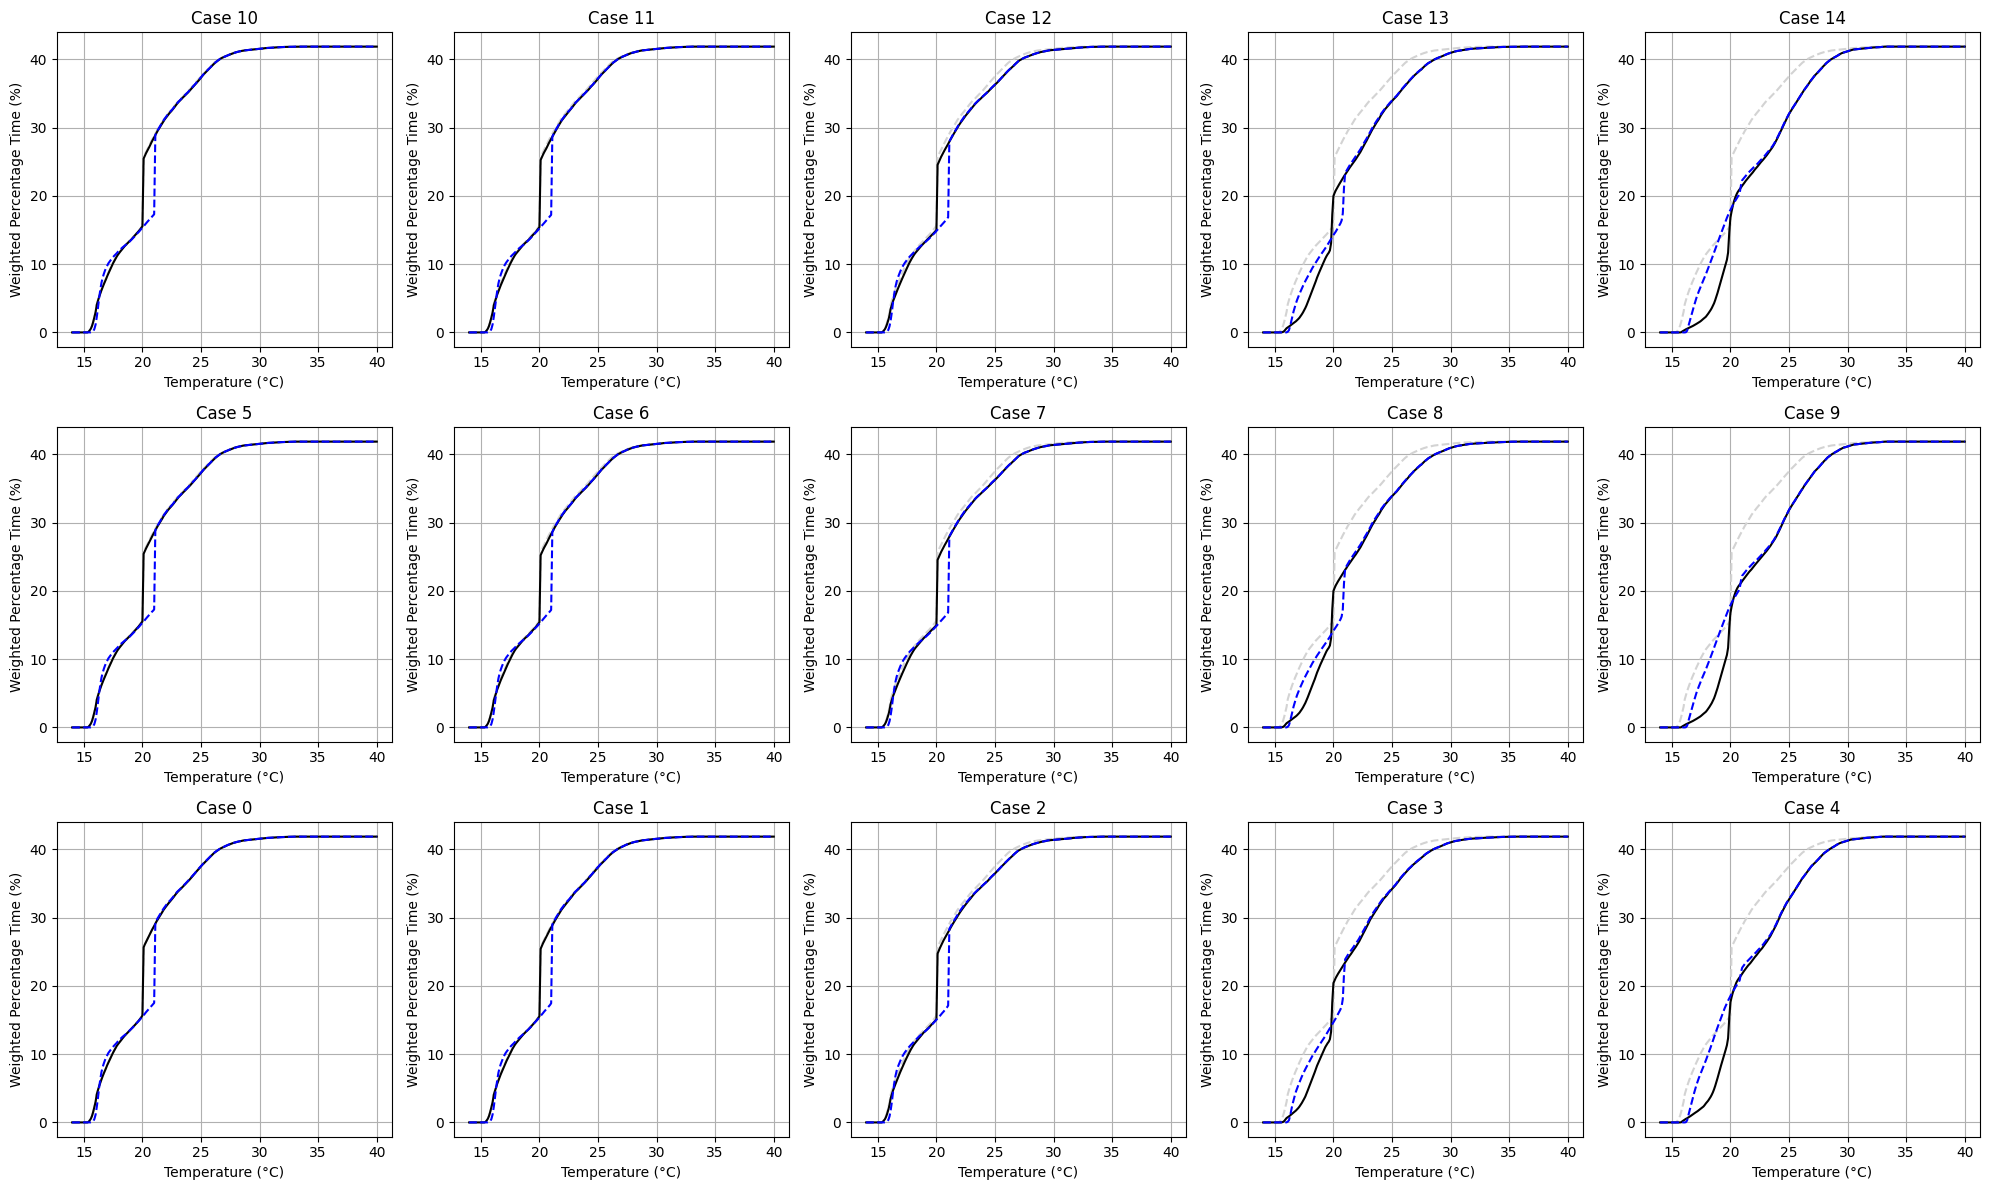

In [124]:
plot_figure("air")

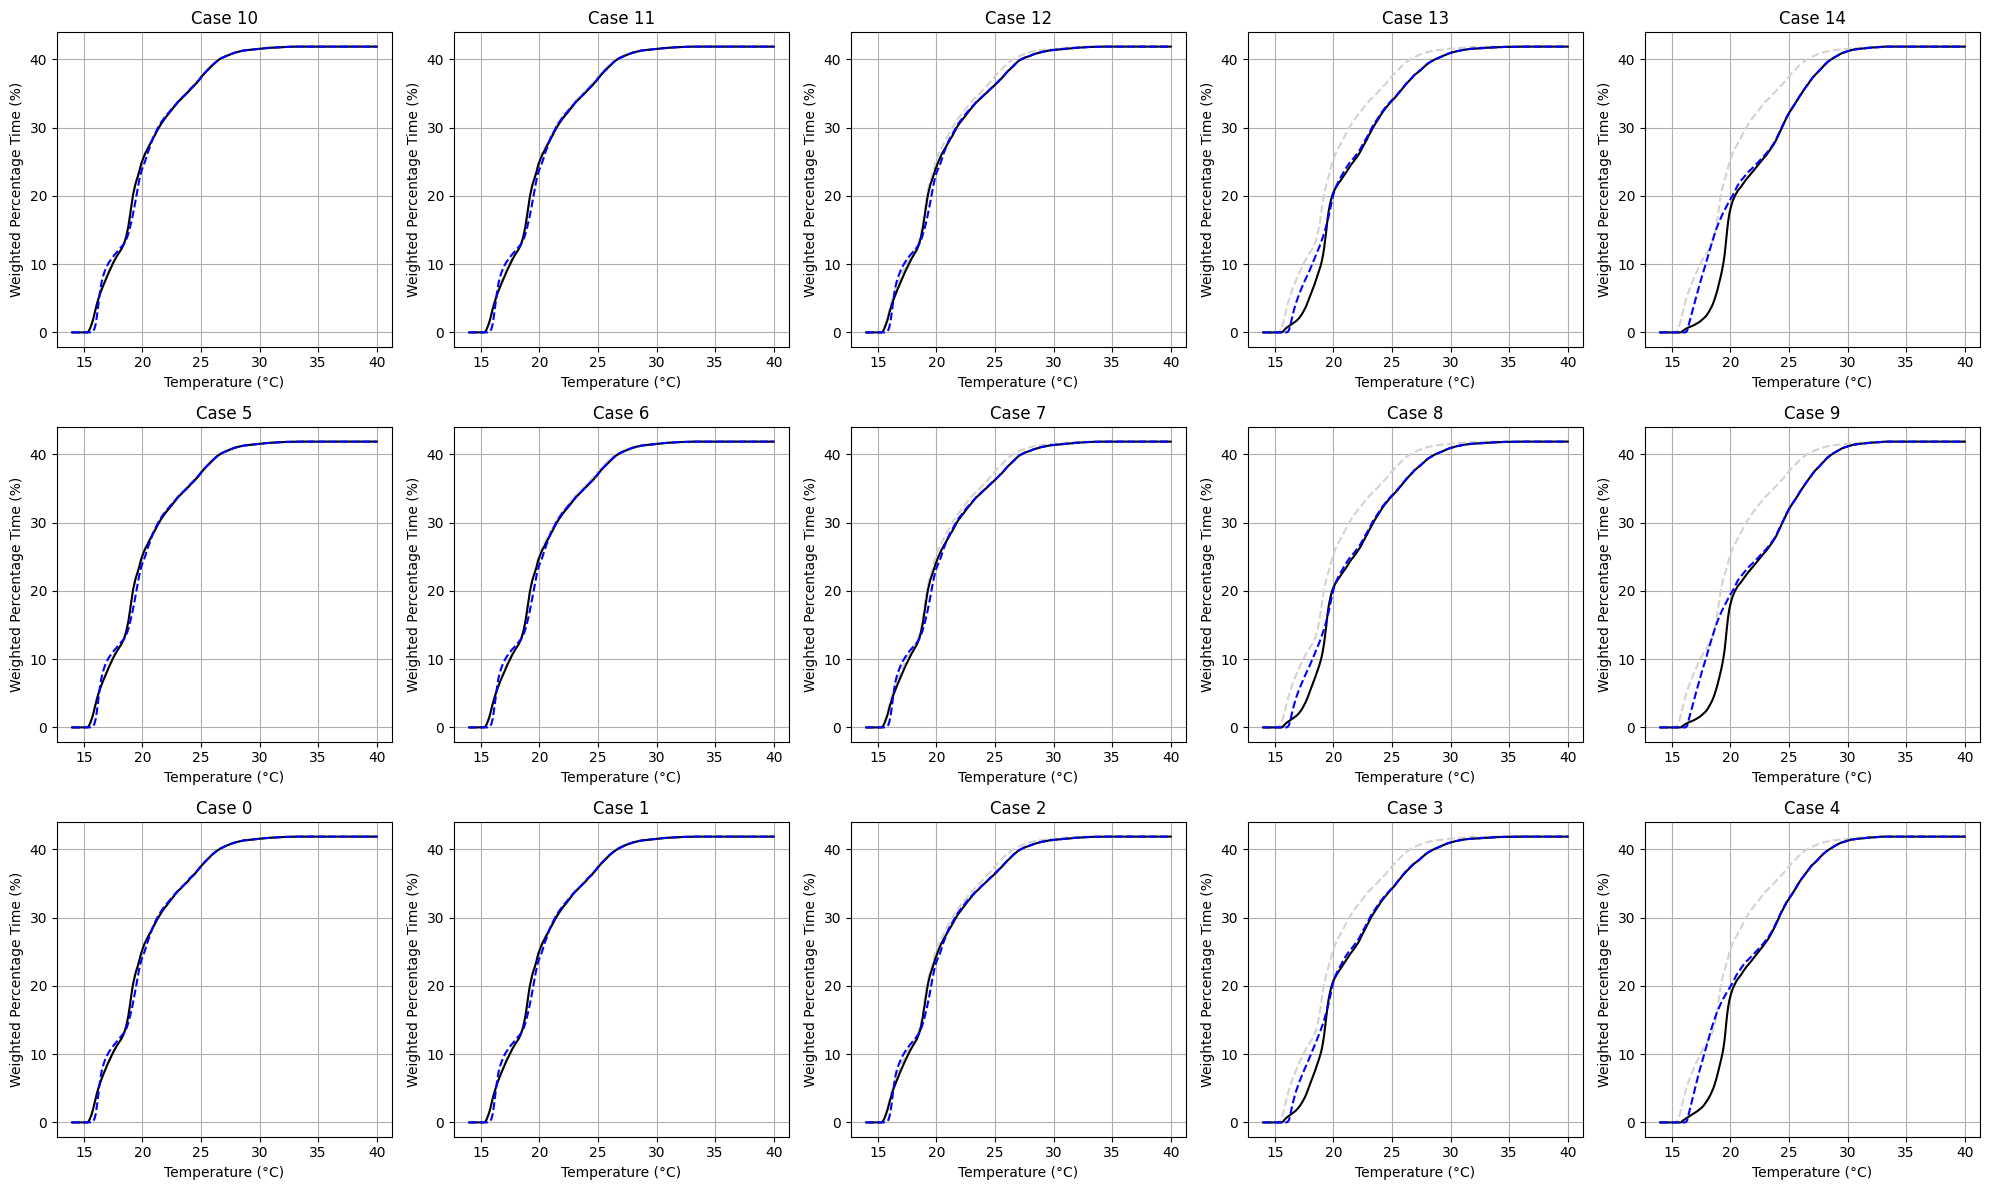

In [123]:
plot_figure("opr")

In [92]:
import matplotlib.pyplot as plt
import pandas as pd
import json

# Path to your JSON file
json_file_path = '/workspaces/CUBES/exp/jack/paper/thermostat_experiment/SI/latest_run/case_0_year_2023_rep_H28_zone_0_inactive_threshold_30_pattern_twice_t_comfort_20.0_t_setback_16.0_tags_latest_run/hourly_metrics.json'

# Open and load the JSON file
with open(json_file_path, 'r') as file:
    data = json.load(file)

# Convert the JSON data into a Pandas DataFrame
hourly_data = pd.DataFrame(data['hourly_data'])

hourly_data = hourly_data *60



In [ ]:
import pandas as pd
import json

# Path to your JSON file
json_file_path = '/workspaces/CUBES/exp/jack/paper/thermostat_experiment/SI/latest_run/case_0_year_2023_rep_H28_zone_0_inactive_threshold_30_pattern_twice_t_comfort_20.0_t_setback_16.0_tags_latest_run/temp.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    data = json.load(file)

def json_normalise_temperature(df):
    df[['Temperature', 'Percentage_Time']] = pd.json_normalize(df['percentage_time'])
    df = df.drop(columns=['percentage_time'])
    return df


# Create DataFrames for the four categories
# 1. In-hours air temperature percentage time
df_in_hours_air_temp_percentage = pd.DataFrame(data['in_hours']['air_temp']['percentage_time'].items(), columns=['zone', 'percentage_time'])
df_in_hours_opr_temp_percentage = pd.DataFrame(data['in_hours']['operative_temp']['percentage_time'].items(), columns=['zone', 'percentage_time'])

# 2. In-hours air temperature total count
df_in_hours_air_temp_count = pd.DataFrame(data['in_hours']['air_temp']['total_count'].items(), columns=['zone', 'total_count'])
df_in_hours_opr_temp_count = pd.DataFrame(data['in_hours']['operative_temp']['total_count'].items(), columns=['zone', 'total_count'])

# 3. Out-of-hours air temperature percentage time
df_out_of_hours_air_temp_percentage = pd.DataFrame(data['out_of_hours']['air_temp']['percentage_time'].items(), columns=['zone', 'percentage_time'])
df_out_of_hours_opr_temp_percentage = pd.DataFrame(data['out_of_hours']['operative_temp']['percentage_time'].items(), columns=['zone', 'percentage_time'])

# 4. Out-of-hours air temperature total count
df_out_of_hours_air_temp_count = pd.DataFrame(data['out_of_hours']['air_temp']['total_count'].items(), columns=['zone', 'total_count'])
df_out_of_hours_opr_temp_count = pd.DataFrame(data['out_of_hours']['operative_temp']['total_count'].items(), columns=['zone', 'total_count'])


# Apply the json_normalise_temperature function to all the temperature percentage DataFrames
df_in_hours_air_temp_percentage = json_normalise_temperature(df_in_hours_air_temp_percentage)
df_in_hours_opr_temp_percentage = json_normalise_temperature(df_in_hours_opr_temp_percentage)
df_out_of_hours_air_temp_percentage = json_normalise_temperature(df_out_of_hours_air_temp_percentage)
df_out_of_hours_opr_temp_percentage = json_normalise_temperature(df_out_of_hours_opr_temp_percentage)


import numpy as np

# Number of minutes in a year (non-leap year)
minutes_in_year = 525600

# Helper function to calculate the combined counts and percentages
def calculate_combined_percentage(in_df, out_df, count_df_in, count_df_out):
    combined_data = []

    for zone in in_df['zone']:
        # Get the percentage time and total count for both in-hours and out-of-hours
        in_percentage = in_df.loc[in_df['zone'] == zone, 'Percentage_Time'].values[0]
        out_percentage = out_df.loc[out_df['zone'] == zone, 'Percentage_Time'].values[0]

        in_count = count_df_in.loc[count_df_in['zone'] == zone, 'total_count'].values[0]
        out_count = count_df_out.loc[count_df_out['zone'] == zone, 'total_count'].values[0]

        # Calculate the actual time spent at each temperature (for in-hours and out-of-hours)
        actual_in_time = np.array(in_percentage) * in_count
        actual_out_time = np.array(out_percentage) * out_count

        # Total actual time spent at each temperature
        total_time_at_temp = actual_in_time + actual_out_time

        # Normalise by the total number of minutes in the year to get the final percentage time
        percentage_time = (total_time_at_temp / minutes_in_year) * 100

        # Store results for the zone
        combined_data.append({
            'zone': zone,
            'Temperature': in_df.loc[in_df['zone'] == zone, 'Temperature'].values[0],
            'Percentage_Time': percentage_time.tolist(),  # Convert to list for easy storage
            'total_count': in_count + out_count
        })

    return pd.DataFrame(combined_data)

# Calculate combined percentage time for air temperature
df_combined_air_temp_percentage = calculate_combined_percentage(
    df_in_hours_air_temp_percentage,
    df_out_of_hours_air_temp_percentage,
    df_in_hours_air_temp_count,
    df_out_of_hours_air_temp_count
)

# Room areas
room_areas = {
    'front_room': 14.04,
    'kitchen': 11.34,
    'backroom': 11.34,
    'hall_downstairs': 7.02,
    'bedroom_1': 11.51,
    'bedroom_2': 12.39,
    'bedroom_3': 6.86,
    'bathroom': 7.105,
    'hall_upstairs': 5.88
}

total_floor_area = sum(room_areas.values())

# Map zones to room areas
zone_to_area = {
    'front_room': room_areas['front_room'],
    'kitchen': room_areas['kitchen'],
    'backroom': room_areas['backroom'],
    'hall_downstairs': room_areas['hall_downstairs'],
    'bedroom_1': room_areas['bedroom_1'],
    'bedroom_2': room_areas['bedroom_2'],
    'bedroom_3': room_areas['bedroom_3'],
    'bathroom': room_areas['bathroom'],
    'hall_upstairs': room_areas['hall_upstairs'],
}

# Function to calculate the weighted average percentage time across rooms
def calculate_weighted_percentage(df, zone_to_area, total_floor_area):
    total_weighted_time = np.zeros(len(df['Temperature'].iloc[0]))  # Initialize array for weighted time
    total_counts = 0  # Initialize total counts for normalisation

    for _, row in df.iterrows():
        zone = row['zone']
        area = zone_to_area.get(zone, 0)  # Get the area for the zone
        total_count = row['total_count']  # Use the total count for normalisation

        # Weight the percentage time by the room area and multiply by the total count
        weighted_time = (np.array(row['Percentage_Time']) * total_count) * (area/total_floor_area)

        # Sum up the weighted times across all zones
        total_weighted_time += weighted_time
        total_counts += total_count  # Track the total counts weighted by area

    # Calculate the final weighted percentage time
    weighted_percentage = total_weighted_time / minutes_in_year

    return weighted_percentage

# Calculate the weighted percentage time for air temperature
weighted_percentage_air_temp = calculate_weighted_percentage(df_combined_air_temp_percentage, zone_to_area, total_floor_area)

# Plot the results
temperature_range = df_combined_air_temp_percentage['Temperature'].iloc[0]
plt.plot(temperature_range, weighted_percentage_air_temp)
plt.xlabel('Temperature (°C)')
plt.ylabel('Weighted Percentage Time (%)')
plt.title('Room-Weighted Percentage Time Spent at Different Temperatures')
plt.grid(True)
plt.show()


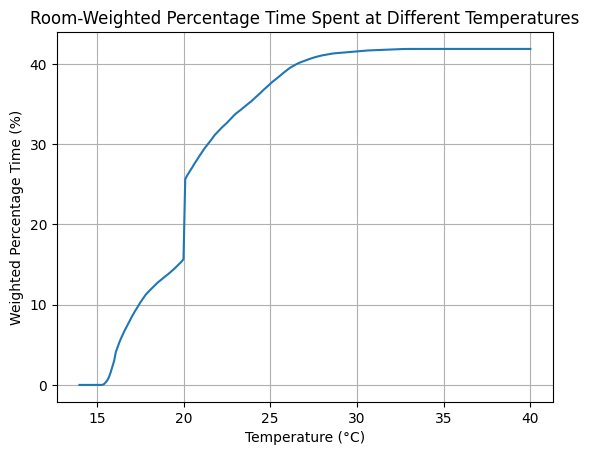

In [95]:
weighted_percentage_air_temp

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 3.59997775e-03, 1.28749663e-01, 5.29154200e-01,
       9.97608359e-01, 1.74616480e+00, 2.83826775e+00, 4.13079079e+00,
       5.43674115e+00, 7.45279049e+00, 8.52985267e+00, 9.60097449e+00,
       1.05346696e+01, 1.13929032e+01, 1.22394625e+01, 1.30150680e+01,
       1.37375388e+01, 1.44718062e+01, 1.52616435e+01, 1.59456826e+01,
       1.66425964e+01, 1.72542656e+01, 1.79209170e+01, 1.85599846e+01,
       1.91479513e+01, 1.97029412e+01, 2.02605288e+01, 2.07220817e+01,
       2.11303340e+01, 2.15332994e+01, 2.19091274e+01, 2.23115212e+01,
       2.26907025e+01, 2.30718572e+01, 2.33935937e+01, 2.37306388e+01,
       2.40339953e+01, 2.43763788e+01, 2.46785475e+01, 2.49663751e+01,
       2.53083088e+01, 2.56610975e+01, 2.60049869e+01, 2.63439655e+01,
      

In [72]:
def calculate_total_year_percentage(in_df, out_df, count_df_in, count_df_out):
    # Total number of minutes in a year (non-leap year)
    total_minutes_in_year = 525600

    # Multiply in-hours percentage by in-hours total count
    in_df['count'] = in_df.apply(lambda row: [
        p * count_df_in.loc[count_df_in['zone'] == row['zone'], 'total_count'].values[0]
        for p in row['Percentage_Time']
    ], axis=1)

    # Multiply out-of-hours percentage by out-of-hours total count
    out_df['count'] = out_df.apply(lambda row: [
        p * count_df_out.loc[count_df_out['zone'] == row['zone'], 'total_count'].values[0]
        for p in row['Percentage_Time']
    ], axis=1)

    # Sum the counts from in-hours and out-of-hours for each temperature
    in_df['total_year_count'] = in_df.apply(lambda row: [
        in_c + out_c for in_c, out_c in zip(
            row['count'], out_df.loc[out_df['zone'] == row['zone'], 'count'].values[0]
        )
    ], axis=1)

    # Normalise the total year count by the total number of minutes in the year
    in_df['whole_year_percentage_time'] = in_df.apply(lambda row: [
        c / total_minutes_in_year for c in row['total_year_count']
    ], axis=1)

    # Return the zone and the calculated whole year percentage times
    return in_df[['zone', 'whole_year_percentage_time']]

# Calculate the total year percentage for air temperature
df_whole_year_air_temp_percentage = calculate_total_year_percentage(
    df_in_hours_air_temp_percentage,
    df_out_of_hours_air_temp_percentage,
    df_in_hours_air_temp_count,
    df_out_of_hours_air_temp_count
)

# Calculate the total year percentage for operative temperature
df_whole_year_opr_temp_percentage = calculate_total_year_percentage(
    df_in_hours_opr_temp_percentage,
    df_out_of_hours_opr_temp_percentage,
    df_in_hours_opr_temp_count,
    df_out_of_hours_opr_temp_count
)



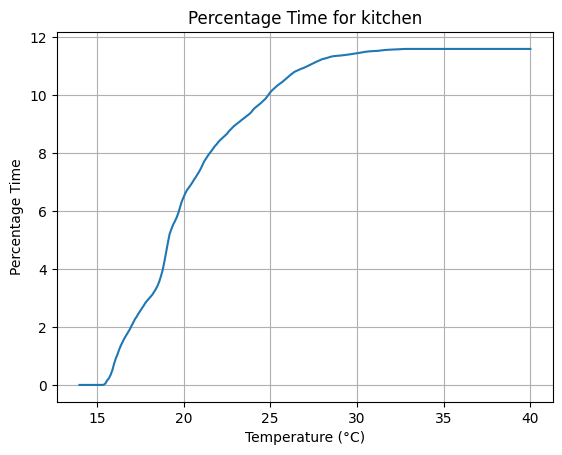

In [74]:
import matplotlib.pyplot as plt
import numpy as np

# Generate the temperature range from 14 to 40 with 0.1 increments
temperature_range = np.arange(14, 40.1, 0.1)  # 0.1 increments, including 40

# Extract the list for the first zone (for example, zone 3) and convert it to a Pandas Series
percentage_time_series = pd.Series(df_whole_year_opr_temp_percentage.iloc[3, 1])

# Ensure that the length of the percentage_time_series matches the temperature_range
if len(percentage_time_series) == len(temperature_range):
    # Plot the percentage time against the temperature range
    plt.plot(temperature_range, percentage_time_series)
    plt.xlabel('Temperature (°C)')  # Label for the x-axis
    plt.ylabel('Percentage Time')    # Label for the y-axis
    plt.title(f"Percentage Time for {df_whole_year_air_temp_percentage.iloc[3, 0]}")
    plt.grid(True)
    plt.show()
else:
    print("The lengths of the temperature range and the percentage time series do not match.")


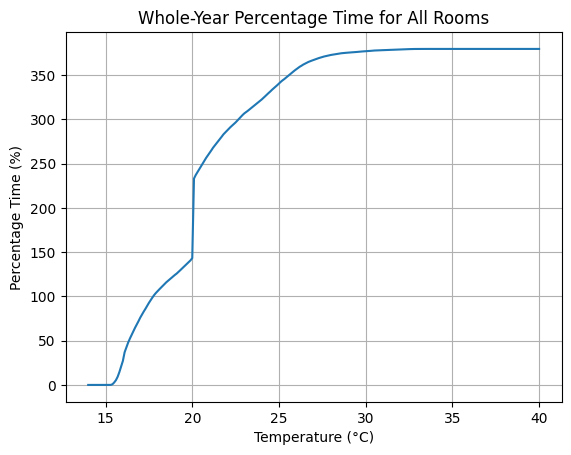

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Room areas
room_areas = {'Frontroom': 14.04,
              'Kitchen': 11.34,
              'Backroom': 11.34,
              'Hall (Downstairs)': 7.02,
              'Bedroom 1': 11.51,
              'Bedroom 2': 12.39,
              'Bedroom 3': 6.86,
              'Bathroom': 7.105,
              'Hall (Upstairs)': 5.88}

# Total floor area
total_floor_area = sum(room_areas.values())

# Number of minutes in a year
minutes_in_year = 525600

# Mapping zones to room names
zone_to_room = {
    'front_room': 'Frontroom',
    'kitchen': 'Kitchen',
    'backroom': 'Backroom',
    'hall_downstairs': 'Hall (Downstairs)',
    'bedroom_1': 'Bedroom 1',
    'bedroom_2': 'Bedroom 2',
    'bedroom_3': 'Bedroom 3',
    'bathroom': 'Bathroom',
    'hall_upstairs': 'Hall (Upstairs)',
}

# Create an empty array to store total counts for each temperature range
total_counts = np.zeros(len(temperature_range))

# Loop through each zone in df_whole_year_air_temp_percentage
for idx, row in df_whole_year_air_temp_percentage.iterrows():
    zone = row['zone']  # Extract the zone name
    percentage_time = row['whole_year_percentage_time']  # Extract the percentage time for the zone

    # Get the corresponding room name and area
    room_name = zone_to_room.get(zone)

    # Get the total count (in-hours + out-of-hours) for the zone
    in_hours_count = df_in_hours_air_temp_count.loc[df_in_hours_air_temp_count['zone'] == zone, 'total_count'].values[0]
    out_hours_count = df_out_of_hours_air_temp_count.loc[df_out_of_hours_air_temp_count['zone'] == zone, 'total_count'].values[0]
    total_room_count = in_hours_count + out_hours_count

    # Multiply the percentage time by the total count for that room to get the actual time spent in each temperature range
    actual_time_in_temp_range = np.array(percentage_time) * total_room_count

    # Add this to the total counts (across all rooms)
    total_counts += actual_time_in_temp_range

# Now normalise by dividing by the total minutes in a year to get the true percentage
whole_year_percentage = (total_counts / minutes_in_year) * 100

# Plot the whole-year percentage time for the house
plt.plot(temperature_range, whole_year_percentage)
plt.xlabel('Temperature (°C)')
plt.ylabel('Percentage Time (%)')
plt.title('Whole-Year Percentage Time for All Rooms')
plt.grid(True)
plt.show()


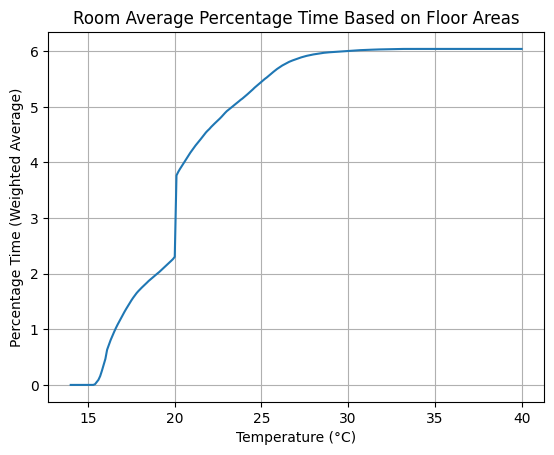

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Room areas
room_areas = {'Frontroom': 14.04,
              'Kitchen': 11.34,
              'Backroom': 11.34,
              'Hall (Downstairs)': 7.02,
              'Bedroom 1': 11.51,
              'Bedroom 2': 12.39,
              'Bedroom 3': 6.86,
              'Bathroom': 7.105,
              'Hall (Upstairs)': 5.88}

total_floor_area = sum(room_areas.values())

# Mapping zones to room names (assuming zone names in DataFrame correspond to these rooms)
zone_to_room = {
    'front_room': 'Frontroom',
    'kitchen': 'Kitchen',
    'backroom': 'Backroom',
    'hall_downstairs': 'Hall (Downstairs)',
    'bedroom_1': 'Bedroom 1',
    'bedroom_2': 'Bedroom 2',
    'bedroom_3': 'Bedroom 3',
    'bathroom': 'Bathroom',
    'hall_upstairs': 'Hall (Upstairs)',
}

# Create an empty list to store the area-weighted temperature data
weighted_percentage_time = np.zeros(len(temperature_range))

# Loop through each zone in df_whole_year_air_temp_percentage
for idx, row in df_whole_year_air_temp_percentage.iterrows():
    zone = row['zone']  # Extract the zone name
    percentage_time = row['whole_year_percentage_time']  # Extract the percentage time for the zone

    # Get the corresponding room name and area
    room_name = zone_to_room.get(zone)
    room_area = room_areas.get(room_name, 0)  # Default to 0 if the room is not found

    # Add the area-weighted percentage time (percentage time is expected in the 0-1 range)
    weighted_percentage_time += np.array(percentage_time) * room_area

# Divide by the total floor area to normalise (convert back to percentage form 0-100%)
room_average_percentage_time = (weighted_percentage_time / total_floor_area) * 100

# Plot the room-average percentage time
plt.plot(temperature_range, room_average_percentage_time)
plt.xlabel('Temperature (°C)')
plt.ylabel('Percentage Time (Weighted Average)')
plt.title('Room Average Percentage Time Based on Floor Areas')
plt.grid(True)
plt.show()


In [39]:
df_in_hours_air_temp_count

,zone,total_count
0,bedroom_2,8243
1,bedroom_1,10719
2,hall_downstairs,12807
3,kitchen,25643
4,hall_upstairs,12807
5,front_room,10902
6,bathroom,13072
7,bedroom_3,15544
8,backroom,11756


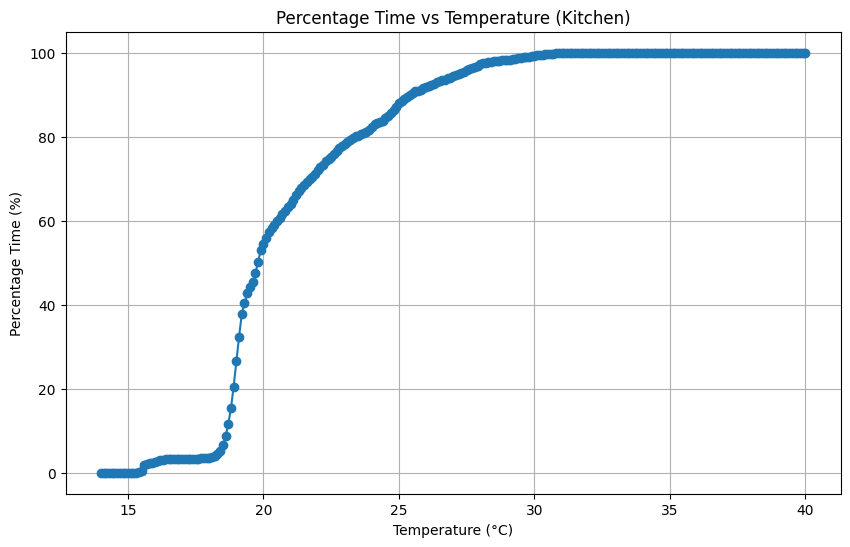

In [ ]:
import matplotlib.pyplot as plt

def plot_percentage_time_for_kitchen(df):
    # Filter the data for kitchen
    kitchen_data = df[df['zone'] == 'kitchen'].iloc[0]

    # Extract the Temperature and Percentage_Time lists
    temperatures = kitchen_data['Temperature']
    percentage_time = kitchen_data['Percentage_Time']

    # Plot the data
    plt.figure(figsize=(10, 6))
    plt.plot(temperatures, percentage_time, marker='o', linestyle='-')
    plt.title('Percentage Time vs Temperature (Kitchen)')
    plt.xlabel('Temperature (°C)')
    plt.ylabel('Percentage Time (%)')
    plt.grid(True)
    plt.show()

# Usage
plot_percentage_time_for_kitchen(df_in_hours_opr_temp_percentage)


In [20]:
df_in_hours_opr_temp_percentage.iloc[3, 1].keys()

dict_keys(['Temperature', 'Percentage_Time'])

In [7]:
df_in_hours_air_temp_percentage

,zone,percentage_time
0,bedroom_2,"{'Temperature': [14.0, 14.1, 14.2, 14.29999999..."
1,bedroom_1,"{'Temperature': [14.0, 14.1, 14.2, 14.29999999..."
2,hall_downstairs,"{'Temperature': [14.0, 14.1, 14.2, 14.29999999..."
3,kitchen,"{'Temperature': [14.0, 14.1, 14.2, 14.29999999..."
4,hall_upstairs,"{'Temperature': [14.0, 14.1, 14.2, 14.29999999..."
5,front_room,"{'Temperature': [14.0, 14.1, 14.2, 14.29999999..."
6,bathroom,"{'Temperature': [14.0, 14.1, 14.2, 14.29999999..."
7,bedroom_3,"{'Temperature': [14.0, 14.1, 14.2, 14.29999999..."
8,backroom,"{'Temperature': [14.0, 14.1, 14.2, 14.29999999..."
